<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/01_mnist_classification_using_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Multi layer perceptron - MNIST digit with Pytorch**
---

![image](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

**Context**

In this tutorial, we will build a neural network model to classify handwritten digits using Pytorch. This model is called as Multi layer perceptron.

**Multi Layer Perceptron (MLP)**

MLP is a type of neural network with an architecture consisting of input, hidden, and output layers of interconnected neurons. This network is capable of learning complex patterns and performing tasks such as classification and regression by adjusting its parameters through training.



**About Handwritten digits - MNIST dataset**

![eight](https://user-images.githubusercontent.com/51207580/59979373-bc052480-9604-11e9-85b8-464367fdc891.png)

Dataset Characteristics:

* 70,000 grayscale images

    * 60,000 training images

    * 10,000 test images

* Image size: 28 × 28 pixels (784 total pixels)

* Pixel range: 0–255

* 10 labels/classes (digits 0–9)

We will build the MLP architecture as below:

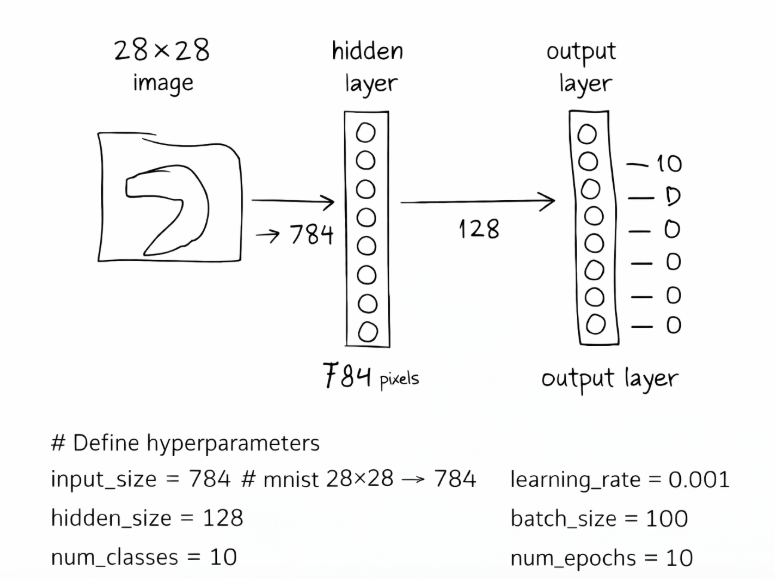

**Initial set up**

In [1]:
# Importing libraries
import torch
import torch.nn as nn                       # Build neural network
import torch.optim as optim                 # Define optimizer
import torchvision.datasets as datasets     # Loading dataset
import torchvision.transforms as transforms # preprocesssing data
from torch.utils.data import DataLoader     # A module used for data preprocessing before inputting it into the model
# DataLoader has several features
# 1. Multiprocessing data processing
# 2. Automatic batching, Previously 1 batch is 1 sample, after batching: 1 batch into 8 samples or 16 samples
# 3. Shuffling, which shuffles every full iteration of the call, e.g.: 0-10 (567812034), (079324561)
# 4. collate_fn, each data call can be passed a collate function to process data

# Set random seeds for reproducibility
torch.manual_seed(42)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Define hyperparameters
input_size = 784 #mnist digit 28x28 -> 784
hidden_size = 128 # Hidden layer
num_classes = 10
learning_rate = 0.001
batch_size = 100
num_epochs = 10 # number of iteration training

**Loading dataset**

In [3]:
# Load MNIST dataset and transform the data to tensor

train_dataset = datasets.MNIST(
    root="data", train=True, transform=transforms.ToTensor(), download=True
) # format:torch.utils.data.Dataset
test_dataset = datasets.MNIST(
    root="data", train=False, transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.75MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.70MB/s]


In [6]:
# Checking data
# Train data
print('Training rows:', len(train_dataset))
# Test data
print('Test rows:', len(test_dataset))

Training rows: 60000
Test rows: 10000


In [8]:
# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break # We only need to check the first batch

torch.Size([100, 1, 28, 28])
torch.Size([100])


In [11]:
# Define MLP model
# Every time we define a neural network module using PyTorch, we must inherit or make nn.Module the parent class.
# So that all functions in the nn.Module class can be used by its derived classes.
class MLP(nn.Module):
    #constructor
    #input_size: The input size of the network
    #hidden_size: The number of nodes in the hidden layer
    #output_size: The number of nodes in the output layer
    #output_size is the number of classes in onehot encoding format 1 -> [0 1 0 0 0 0 0 0 0]
    def __init__(self, input_size, hidden_size, num_classes):
        # We must call the constructor of the super class (the parent class)
        super(MLP, self).__init__()
        # define self.fc1 (fully connected 1) nn.Linear(input_size, output_size), output_size represents the output size of the node.
        self.fc1 = nn.Linear(input_size, hidden_size)
        # activation function -> max(0, value)
        self.relu = nn.ReLU()
        #define the second layer of the network with an input of hidden size, and an output of num_class
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# MLP model
model = MLP(input_size, hidden_size, num_classes).to(device)

* node 1 = i_1 * w11 + i_2 * w12 + b

* node 2 = i_1 * w21 + i_2 * w22 + b

* node 3 = i_1 * w31 + i_2 * w32 + b

i: input_, w : weight_, b: bias

In [12]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss() #loss function is a module used to penalize our model and check whether the prediction results are correct
optimizer = optim.Adam(model.parameters(), lr=learning_rate) #optimizer is a module used to update the parameters (usually weights) in the model

**Model training**

In [13]:
# Function for model training
def train(model, data_loader, criterion, optimizer, device):

    # We change our model mode to train
    model.train()

    # Variable to store several metrics that will be displayed later during the training process
    total_loss = 0
    correct = 0
    total = 0

    # Iterate data over the data loader, images, and labels
    for batch_idx, (images, labels) in enumerate(data_loader):
        images = images.to(device) #We change our image device to the desired device function
        labels = labels.to(device) #We change the labels as well

        optimizer.zero_grad()#We delete all gradients stored by the optimizer
        outputs = model(images) #Feedforward process, we predict the input data to the model
        loss = criterion(outputs, labels) # The process of comparing the predicted output with the ground truth or labels
        loss.backward()#the backpropagation process
        optimizer.step()#The process of changing the parameters of the results Backpropagation

        total_loss += loss.item() #we store the loss value


        #an operation to calculate accuracy
        _, predicted = outputs.max(1)#B,num_class
        total += labels.size(0) #we store the total value
        correct += predicted.eq(labels).sum().item() #storing the number of correct values ​​into the variable correct

    return total_loss / len(data_loader), 100.0 * correct / total

**Model Evaluation**

In [14]:
# Model evaluation

from sklearn.metrics import precision_score, recall_score, f1_score
# Function for model evaluation
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    precision = precision_score(true_labels, predicted_labels, average="macro")# precision metrics
    recall = recall_score(true_labels, predicted_labels, average="macro")# sensitivity metrics
    f1 = f1_score(true_labels, predicted_labels, average="macro")# f1 metrics to balance precision dan recall
    #precision, TP/(TP+FP)
    #recall, TP/(TP+FN)
    #f1 score, 2*(Precision*Recall)/Precision+Recall
    return (
        total_loss / len(data_loader),
        100.0 * correct / total,
        precision,
        recall,
        f1,
        predicted_labels,
        true_labels,
    )

In [15]:
# Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, precision, recall, f1, predicted_labels, true_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )

Epoch [1/10], Train Loss: 0.3850, Train Acc: 89.64%, Test Loss: 0.2103, Test Acc: 93.89%, Precision: 0.9389, Recall: 0.9379, F1: 0.9381
Epoch [2/10], Train Loss: 0.1809, Train Acc: 94.87%, Test Loss: 0.1463, Test Acc: 95.80%, Precision: 0.9581, Recall: 0.9574, F1: 0.9576
Epoch [3/10], Train Loss: 0.1272, Train Acc: 96.33%, Test Loss: 0.1227, Test Acc: 96.26%, Precision: 0.9621, Recall: 0.9625, F1: 0.9622
Epoch [4/10], Train Loss: 0.0969, Train Acc: 97.19%, Test Loss: 0.1018, Test Acc: 96.91%, Precision: 0.9691, Recall: 0.9687, F1: 0.9689
Epoch [5/10], Train Loss: 0.0769, Train Acc: 97.80%, Test Loss: 0.0892, Test Acc: 97.38%, Precision: 0.9737, Recall: 0.9737, F1: 0.9736
Epoch [6/10], Train Loss: 0.0628, Train Acc: 98.13%, Test Loss: 0.0832, Test Acc: 97.54%, Precision: 0.9755, Recall: 0.9751, F1: 0.9752
Epoch [7/10], Train Loss: 0.0524, Train Acc: 98.42%, Test Loss: 0.0808, Test Acc: 97.62%, Precision: 0.9762, Recall: 0.9759, F1: 0.9760
Epoch [8/10], Train Loss: 0.0439, Train Acc: 98.

**Confusion matrix**

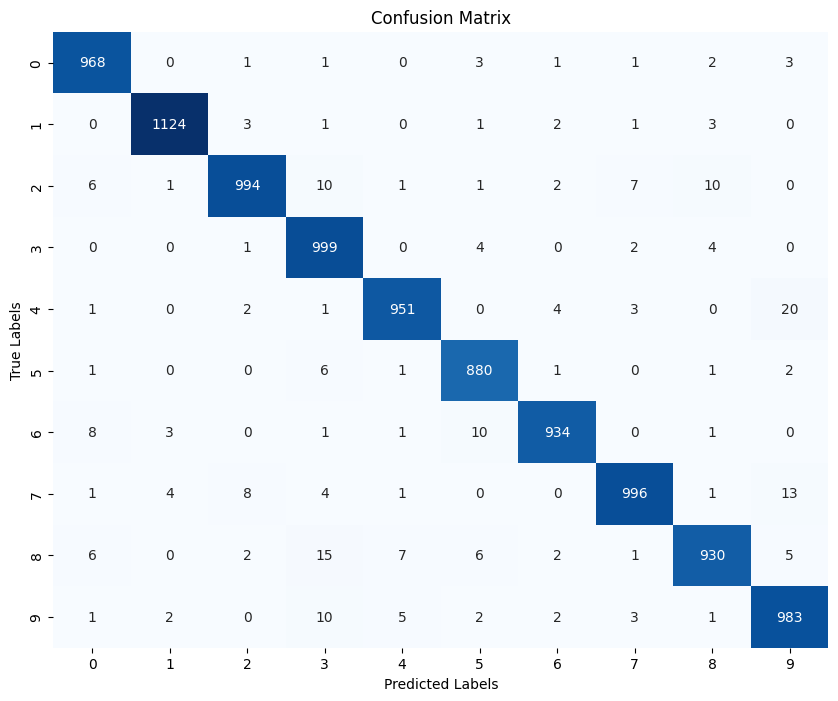

In [16]:
# Confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

**Simulate prediction**

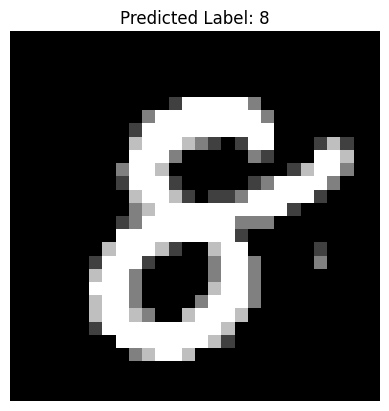

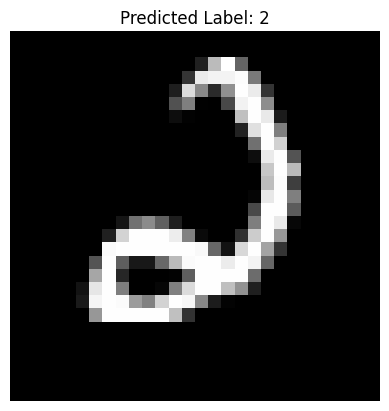

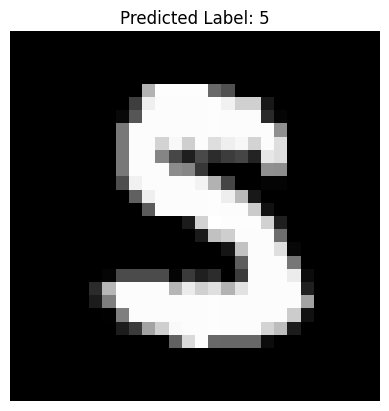

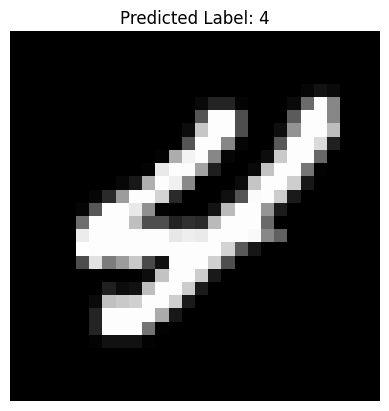

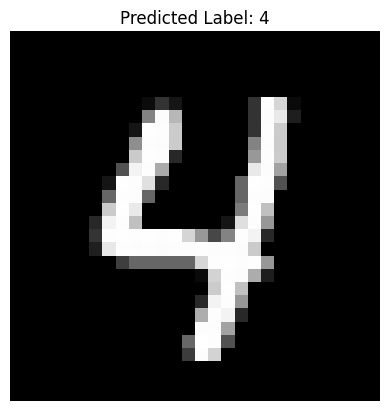

In [17]:
# Model simulation

import numpy as np
import matplotlib.pyplot as plt

# Function to display the image and predicted label
def show_prediction(image, predicted_label):
    #plt.imshow: display image
    plt.imshow(image.squeeze(), cmap="gray") #C,H,W -> h,w
    # we turn off the axis so that the show image is smoother
    plt.axis("off")
    # then give the predicted label to title
    plt.title(f"Predicted Label: {predicted_label}")
    plt.show()

# Specify the number of sample images to test
num_samples = 5

# Select random sample images from the test set
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for index in sample_indices:
    sample_image, sample_label = test_dataset[index]
    sample_image = sample_image.to(device).unsqueeze(0) #because the input model wants our image to be in a format: Batch, h, w

    # Make the prediction
    model.eval()# change mode model to eval
    with torch.no_grad():# this is an operation to lighten our gpu
        output = model(sample_image)# output prediction from model with input sample_img
        _, predicted = torch.max(output.data, 1) #we get the maximum index from torch.max

    # Convert the tensor to a numpy array
    sample_image = sample_image.cpu().squeeze().numpy()# Convert format B,C,H,W -> C,H,W

    # Display the sample image and predicted label
    show_prediction(sample_image, predicted.item())